In [47]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Memuat dan Menampilkan Citra CCTV Asli serta Citra Grayscale
Kode di bawah ini digunakan untuk membaca citra backup.jpg (citra CCTV berkualitas rendah) menggunakan cv.imread(). Citra asli yang memiliki format warna BGR (standar OpenCV) dikonversi terlebih dahulu ke format RGB agar dapat ditampilkan dengan warna yang benar.
Selanjutnya, citra dikonversi ke grayscale menggunakan cv.cvtColor() dengan kode COLOR_BGR2GRAY. Konversi ke grayscale dilakukan karena sebagian besar teknik pengolahan citra (smoothing,sharpening, deteksi tepi, dan thresholding) lebih efektif dan sederhana diterapkan pada citra satu kanal.

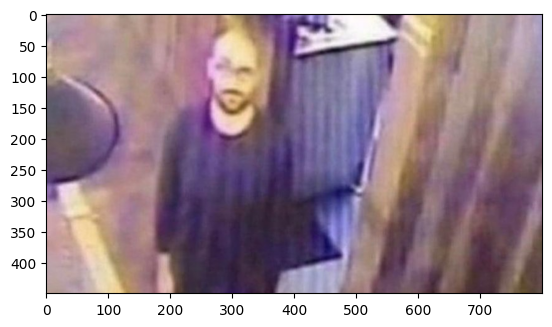

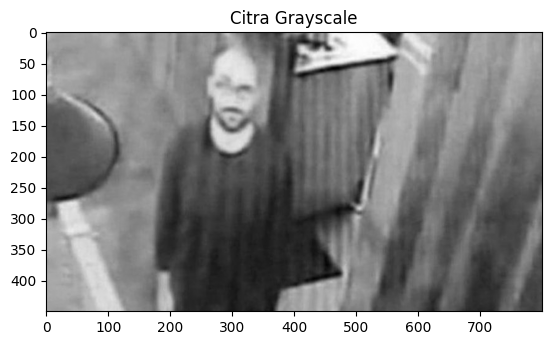

In [48]:
cctv = cv.imread("backup.jpg")
plt.imshow(cv.cvtColor(cctv, cv.COLOR_BGR2RGB))
plt.show()

cctv_gray = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)
plt.title("Citra Grayscale")
plt.imshow(cctv_gray, cmap = "gray")
plt.show()

In [49]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2

    # Padding manual
    padded = np.zeros((height + 2*pad, width + 2*pad), dtype=img.dtype)
    padded[pad:pad+height, pad:pad+width] = img

    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    # rumus median manual
                    values = sorted(values)
                    canvas[i, j] = values[len(values) // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    # hitung kemunculan
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

## Fungsi filter
Fungsi filter() dibuat untuk melakukan filtering manual pada citra grayscale. Fungsi ini mendukung tiga mode filtering: mean, median, dan modus. Pertama, fungsi menghitung ukuran padding berdasarkan setengah dari ukuran kernel, kemudian membuat citra padded dengan menambahkan border nol di sekeliling citra asli agar proses filtering pada tepi citra dapat dilakukan dengan benar. Selanjutnya, dibuat kanvas kosong untuk menyimpan hasil. Melalui dua perulangan for pada tinggi dan lebar citra, setiap piksel diolah dengan mengambil wilayah tetangga sesuai ukuran kernel. Pada mode 'mean', nilai rata-rata seluruh piksel dalam kernel dihitung dan dibulatkan. Pada mode 'median', semua nilai piksel diurutkan kemudian diambil nilai tengahnya. Sedangkan pada mode 'modus', fungsi menghitung frekuensi kemunculan setiap nilai dan mengambil nilai yang paling sering muncul. Fungsi ini sangat penting untuk meredam noise pada citra CCTV backup.jpg sebelum dilakukan proses sharpening dan deteksi tepi.

In [50]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    
    # Padding nol manual
    height, width = img.shape
    padded = np.zeros((height + 2*pad_size, width + 2*pad_size), dtype=np.float32)
    padded[pad_size:pad_size+height, pad_size:pad_size+width] = img
    
    canvas = np.zeros_like(img, dtype=np.float32)
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    
    return canvas

## Fungsi Konvolusi
Fungsi convolution() digunakan untuk melakukan operasi konvolusi secara manual pada citra grayscale. Fungsi ini menerima citra input dan kernel (matriks filter) sebagai parameter. Pertama, ukuran padding dihitung berdasarkan setengah dari ukuran kernel, kemudian dibuat citra padded dengan padding nol di sekitar citra asli agar konvolusi pada piksel tepi tetap dapat dilakukan. Selanjutnya, dibuat kanvas kosong bertipe float32 untuk menyimpan hasil konvolusi. Melalui dua perulangan for pada tinggi dan lebar citra, setiap piksel diolah dengan mengambil wilayah tetangga sesuai ukuran kernel, kemudian dilakukan perkalian elemen-wise antara wilayah tersebut dengan kernel dan dijumlahkan seluruhnya `(np.sum(region * kernel))`. Hasil konvolusi ini nantinya akan digunakan untuk proses sharpening maupun deteksi tepi (seperti Sobel, Prewitt, atau Roberts) pada citra CCTV backup.jpg.

In [51]:
# Kernel smoothing (menghaluskan)
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# Kernel sharpening (mempertajam)
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

### Kernel Sharping dan Smoothing
Kernel kernelSmoothing dan kernelSharpening didefinisikan untuk digunakan bersama fungsi convolution() yang telah dibuat sebelumnya. Kernel smoothing berisi nilai rata-rata tertimbang dengan bobot lebih tinggi di tengah (1/5) dan bobot lebih rendah di pinggir (1/10), berfungsi untuk menghaluskan citra serta meredam noise pada citra CCTV backup.jpg. Sedangkan kernel sharpening menggunakan nilai positif yang lebih tinggi di tengah (8/9) dan nilai rendah di sekitarnya (1/9), bertujuan untuk mempertajam tepi dan detail citra dengan cara menonjolkan perbedaan intensitas antar piksel. Kedua kernel ini merupakan filter 3x3 yang akan diterapkan melalui operasi konvolusi manual, sehingga memungkinkan perbandingan hasil smoothing, sharpening, serta kombinasi keduanya.

In [52]:
# Sobel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

# Prewitt
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

# Roberts
robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

### Kernel Operator
Kernel Sobel, Prewitt, dan Roberts didefinisikan untuk melakukan deteksi tepi secara manual pada citra CCTV menggunakan fungsi convolution(). Kernel Sobel (sobelX dan sobelY) dirancang untuk mendeteksi perubahan intensitas horizontal dan vertikal dengan memberikan bobot lebih besar pada piksel yang lebih jauh dari pusat, sehingga lebih sensitif terhadap noise namun menghasilkan tepi yang lebih halus. Kernel Prewitt (prewittX dan prewittY) memiliki bobot yang sama pada setiap arah, sehingga lebih sederhana dan cepat namun cenderung lebih sensitif terhadap noise dibandingkan Sobel. Sementara itu, kernel Roberts (robertsX dan robertsY) berukuran 2x2 yang mendeteksi tepi secara diagonal, sehingga lebih responsif terhadap tepi diagonal namun hasilnya biasanya lebih kasar dan rentan terhadap noise. Ketiga pasang kernel ini nantinya akan digunakan untuk mendeteksi tepi pada citra backup.jpg, baik secara terpisah maupun dikombinasikan.

In [53]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    
    # Gabung gradien absolut
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

## Fungsi edge
Fungsi edge() digunakan untuk melakukan deteksi tepi secara manual dengan menggabungkan gradien horizontal dan vertikal. Fungsi ini memanggil fungsi convolution() dua kali, yaitu untuk kernel X (kernelx) menghasilkan gx dan kernel Y (kernely) menghasilkan gy. Kedua hasil konvolusi tersebut kemudian dijumlahkan setelah diambil nilai absolutnya (np.abs(gx) + np.abs(gy)) untuk mendapatkan magnitude gradien keseluruhan. Hasil penjumlahan selanjutnya dinormalisasi ke rentang 0-255 agar nilai piksel sesuai dengan format citra grayscale standar, kemudian dilakukan clipping menggunakan np.clip() dan dikonversi ke tipe uint8.

In [54]:
def tambah (citra1, citra2):
    return citra1 + citra2

## Fungsi Tambah Citra
Fungsi tambah(citra1, citra2) adalah fungsi sederhana yang dibuat untuk menjumlahkan dua citra secara manual. Fungsi ini menerima dua citra sebagai input dan mengembalikan hasil penjumlahan piksel per piksel antara citra1 dan citra2.

### Menampilkan dan menerapkan smoothing dan sharpenig  pada citra
Kode di atas digunakan untuk menerapkan proses smoothing, sharpening, serta kombinasi keduanya pada citra grayscale cctv_gray. Pertama, citra dikonversi ke tipe float32 kemudian dilakukan konvolusi menggunakan kernelSmoothing untuk menghasilkan citra smooth yang lebih halus dan noise-nya berkurang. Selanjutnya dilakukan konvolusi dengan kernelSharpening untuk menghasilkan citra sharp yang lebih tajam. Kedua hasil tersebut kemudian dijumlahkan menggunakan fungsi tambah() dan disimpan pada variabel smothsharp

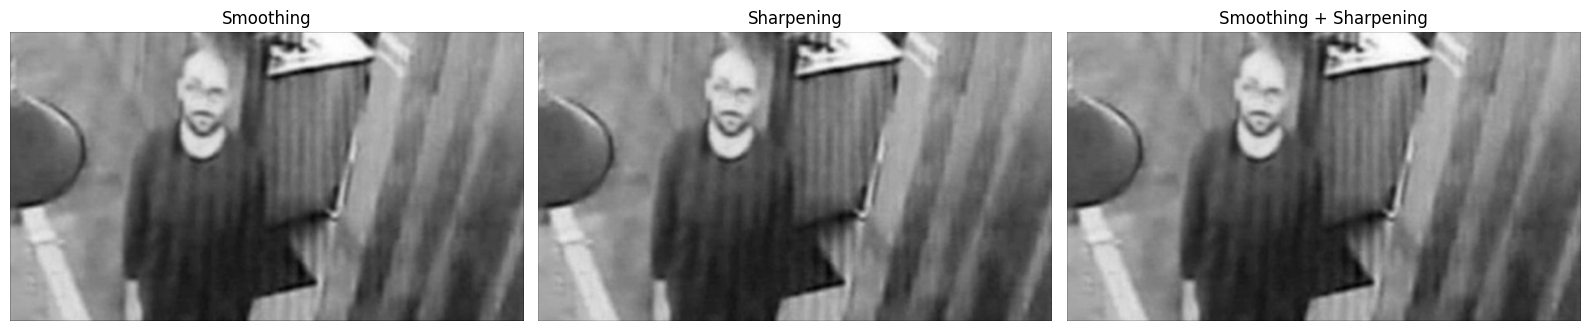

In [55]:
smooth = convolution(cctv_gray.astype(np.float32), kernelSmoothing)
sharp = convolution(cctv_gray.astype(np.float32), kernelSharpening)
smothsharp = tambah(smooth, sharp)

plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(smooth, cmap='gray')
plt.title("Smoothing")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp, cmap='gray')
plt.title("Sharpening")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smothsharp, cmap='gray')
plt.title("Smoothing + Sharpening")
plt.axis('off')

plt.tight_layout()

### Analisis Perbedaan ketiga gambar
Pada gambar Smoothing, citra jadi jauh lebih halus dan bersih. Noise-nya banyak yang hilang, tapi sayangnya gambar jadi agak blur dan detailnya kurang tajam. Wajah, baju, sama latar belakang semuanya terlihat agak kabur. Sedangkan pada gambar Sharpening, citranya jadi paling tajam. Tepi-tepi dan detailnya kelihatan banget, tapi noise yang tadinya kecil jadi ikut tajam juga. Hasilnya agak berisik dan banyak garis-garis kecil yang mengganggu, terutama di background. Untuk gambar Smoothing + Sharpening, menurut saya ini hasil yang paling balance. Noise-nya lebih terkendali dibanding sharpening doang, tapi tetap lebih tajam daripada smoothing saja. Detail orangnya lebih kelihatan jelas tanpa terlalu banyak gangguan. Walau begitu, masih agak kurang tajam di beberapa bagian.
Intinya, smoothing bikin gambar enak dilihat tapi kurang jelas, sharpening bikin tajam tapi noisy, dan kombinasi keduanya jadi pilihan tengah-tengah yang paling masuk akal buat citra CCTV.

### Menampilkan citra hasil penerapan mode mean, median, dan modus
Kode di dibawah digunakan untuk membandingkan hasil filtering dengan tiga metode yang berbeda (mean, median, dan modus) serta dua ukuran kernel yang berbeda (3x3 dan 9x9). Lalu memanggil fungsi filter() yang sudah dibuat sebelumnya untuk menghasilkan enam citra: mean3, mean9, median3, median9, modus3, dan modus9. Kemudian keenam hasil tersebut ditampilkan secara berdampingan menggunakan subplot agar mudah dibandingkan.

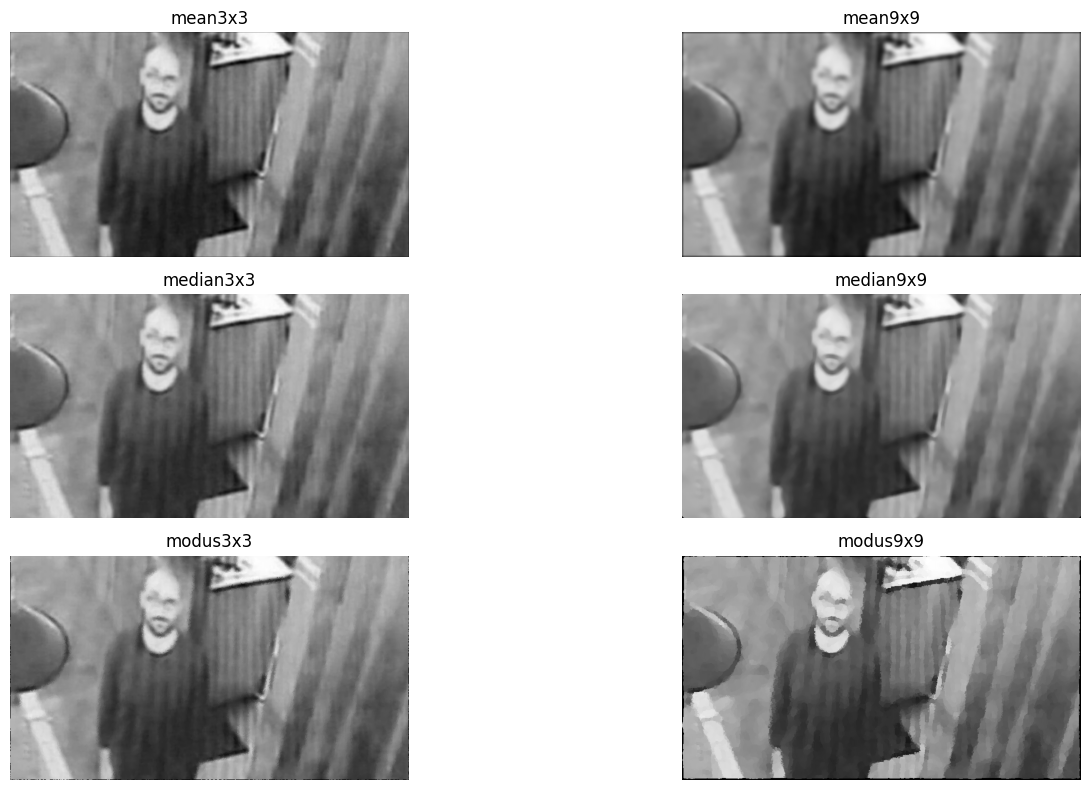

In [56]:
mean3 = filter(cctv_gray, 3, 'mean')
mean9 = filter(cctv_gray, 9, 'mean')
median3 = filter(cctv_gray, 3, 'median')
median9 = filter(cctv_gray, 9, 'median')
modus3 = filter(cctv_gray, 3, 'modus')
modus9 = filter(cctv_gray, 9, 'modus')

plt.figure(figsize=(16, 8))

plt.subplot(3, 2, 1)
plt.imshow(smooth, cmap='gray')
plt.title("mean3x3")
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(mean9, cmap='gray')
plt.title("mean9x9")
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(median3, cmap='gray')
plt.title("median3x3")
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(median9, cmap='gray')
plt.title("median9x9")
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(modus3, cmap='gray')
plt.title("modus3x3")
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(modus9, cmap='gray')
plt.title("modus9x9")
plt.axis('off')

plt.tight_layout()

### Mean
mean yang 3x3 dan 9x9 berbeda dimana yang 9x9 lebih ngeblur atau noise karena ukurannya yang berbeda, dimana ukuran piksel di mean itu bergantung dengan ukuran yang di berikan, jadi ukuran pikselnya akan di perbedar yang membuat gambarnya lebih nge blur

### Median
Ini menurut saya yang paling bagus di antara ketiganya. median3x3 sudah cukup halus dan noise berkurang tanpa terlalu mengaburkan gambar. Bahkan median9x9 masih cukup mempertahankan bentuk orangnya dibanding mean9x9. Median lebih efektif menghilangkan noise acak (salt & pepper) sambil lebih menjaga tepi objek.

### Modus
modus 3x3 dan 9x9 berbeda jika di lihat dari citra yang dihasilkan, 9x9 terdapat bingkai di samping citra yang lebih besar, karena ukuran nya yang lebih besar. Karena modus itu dia mengabaikan nilai nilai pinggirannya


### Deteksi Tepi pada Semua Hasil Filter dengan Tiga Operator
Kode di bawah digunakan untuk menerapkan deteksi tepi pada seluruh hasil filter yang telah dibuat sebelumnya menggunakan tiga operator sekaligus yaitu Sobel, Prewitt, dan Roberts. Pertama, semua hasil filter disimpan dalam dictionary filtered_imgs agar bisa diiterasi secara otomatis. Selanjutnya, perulangan luar mengiterasi tiap operator deteksi tepi beserta kernel x dan y-nya, sedangkan perulangan dalam menerapkan fungsi edge ke setiap hasil filter dan menampilkannya dalam grid 2x4.
Tujuan dari proses ini adalah membandingkan bagaimana setiap kombinasi filter dan operator tepi mempengaruhi hasil deteksi, misalnya apakah Mean 9x9 yang sangat blur menghasilkan tepi yang lebih sedikit dibanding Mean 3x3, atau apakah Roberts lebih sensitif noise dibanding Sobel ketika diterapkan pada hasil Modus filter yang memiliki efek posterisasi. Dengan menampilkan semua kombinasi sekaligus, analisis perbandingan antar metode menjadi lebih mudah dan komprehensif.

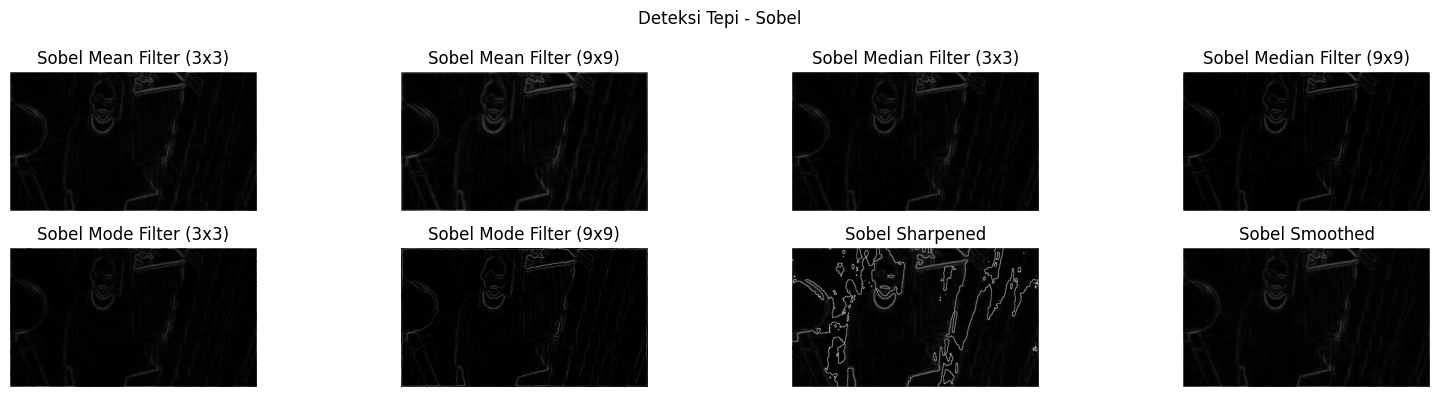

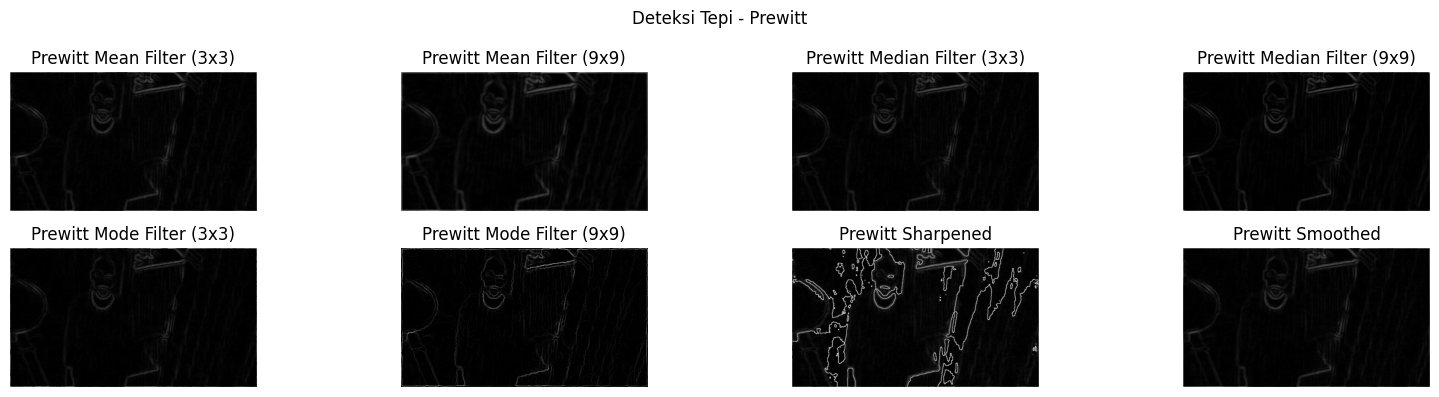

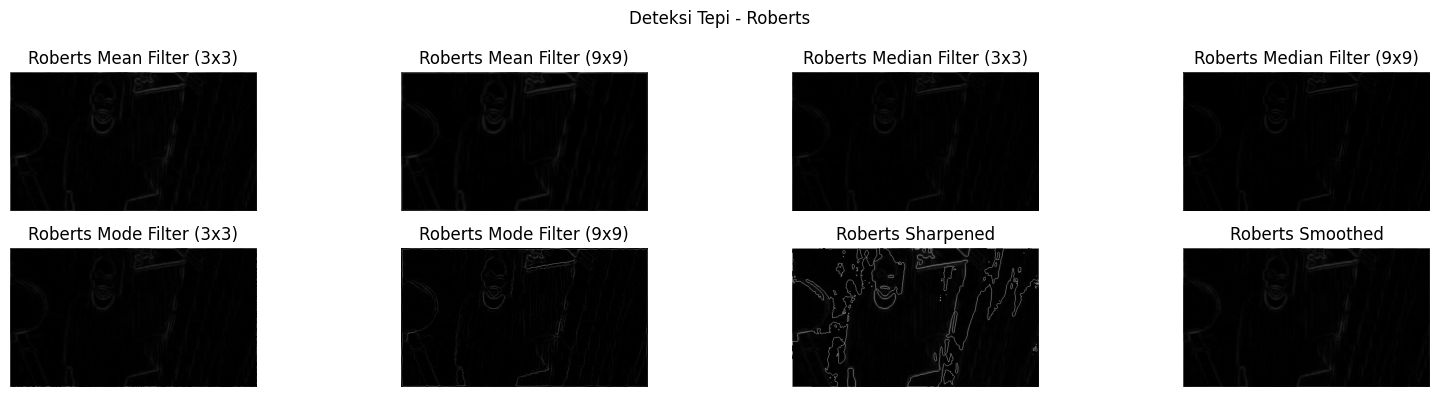

In [57]:
filtered_imgs = {
    'Mean Filter (3x3)': mean3,   'Mean Filter (9x9)': mean9,
    'Median Filter (3x3)': median3, 'Median Filter (9x9)': median9,
    'Mode Filter (3x3)': modus3,  'Mode Filter (9x9)': modus9,
    'Sharpened': sharp.astype(np.uint8),
    'Smoothed': smooth.astype(np.uint8)
}

for detector_name, (kx, ky) in [('Sobel', (sobelX, sobelY)),
                                  ('Prewitt', (prewittX, prewittY)),
                                  ('Roberts', (robertsX, robertsY))]:
    plt.figure(figsize=(16, 4))
    plt.suptitle(f'Deteksi Tepi - {detector_name}')
    for i, (title, img_f) in enumerate(filtered_imgs.items()):
        hasil_tepi = edge(img_f, kx, ky)
        plt.subplot(2, 4, i+1)
        plt.imshow(hasil_tepi, cmap='gray')
        plt.title(f'{detector_name} {title}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Analisis Hasil Deteksi Tepi pada Citra CCTV

Sobel + Mean Filter: Mean 3x3 menghasilkan tepi yang cukup terlihat namun sedikit noise. Mean 9x9 menghasilkan tepi yang lebih halus dan lebih sedikit karena blur yang lebih ekstrem menghilangkan banyak detail tepi, terutama pada area tekstur background.

Sobel + Median Filter: Median 3x3 menghasilkan tepi yang bersih dan cukup detail karena median mempertahankan tepi sambil menghilangkan noise. Median 9x9 menghasilkan tepi yang lebih sedikit namun lebih tegas pada kontur utama orang karena noise titik sudah bersih.

Sobel + Modus Filter: Modus 3x3 menghasilkan tepi yang cukup jelas pada batas area posterisasi. Modus 9x9 menghasilkan tepi yang sangat tegas dan sedikit karena posterisasi yang ekstrem membuat batas antar blok warna menjadi sangat kontras sehingga hanya tepi utama yang terdeteksi.

Sobel + Sharpened: Menghasilkan tepi paling banyak dan paling berisik karena sharpening mempertegas semua perubahan intensitas termasuk noise, sehingga hampir seluruh area gambar terdeteksi sebagai tepi. Ini terlihat dari gambar yang paling terang dibanding yang lain.

Sobel + Smoothed: Menghasilkan tepi yang paling bersih dan halus karena smoothing melembutkan semua perubahan intensitas kecil. Hanya kontur utama yang kontrasnya sangat tinggi yang masih terdeteksi.

Prewitt: Secara keseluruhan hasilnya sangat mirip dengan Sobel karena konsepnya sama yaitu deteksi horizontal dan vertikal. Perbedaan tipis terlihat pada area noise — Prewitt sedikit lebih sensitif karena tidak ada pembobotan tambahan di titik tengah kernel seperti Sobel.

Roberts: Hasil Roberts secara keseluruhan paling gelap dan paling sedikit tepi dibanding Sobel dan Prewitt. Ini karena kernel Roberts berukuran 2x2 dan hanya mendeteksi perubahan diagonal, sehingga banyak tepi horizontal dan vertikal tidak terdeteksi. Roberts + Sharpened tetap menghasilkan tepi paling banyak namun masih lebih sedikit dibanding Sobel/Prewitt + Sharpened.

Kesimpulan perbandingan: Kombinasi terbaik untuk citra CCTV berkualitas rendah ini adalah **Sobel atau Prewitt + Median Filter** karena menghasilkan tepi yang bersih, cukup detail, dan tidak terlalu banyak noise. Sharpening sebaiknya dihindari sebelum deteksi tepi pada citra berkualitas rendah karena justru memperbesar noise yang ada.

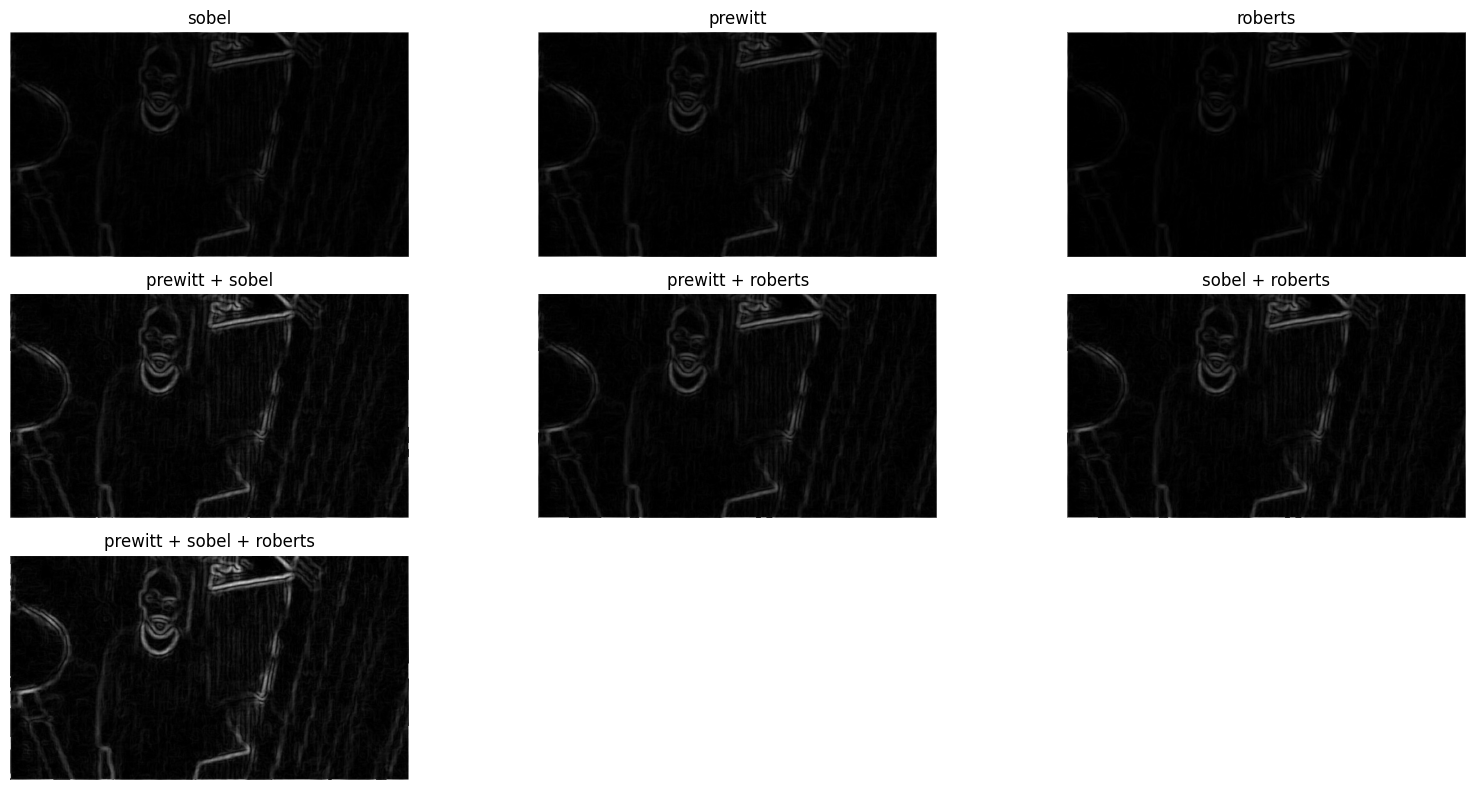

In [58]:
sobel = edge(smooth, sobelX, sobelY)
prewitt = edge(smooth, prewittX, prewittY)
roberts = edge(smooth , robertsX, robertsY)

prewittsobel = tambah(prewitt, sobel)
prewittroberts = tambah(prewitt, roberts)
sobelroberts = tambah(roberts, sobel)

ketiganya = tambah(prewittroberts, sobel)

plt.figure(figsize=(16, 8))

plt.subplot(3, 3, 1)
plt.imshow(sobel, cmap='gray')
plt.title("sobel")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(prewitt, cmap='gray')
plt.title("prewitt")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(roberts, cmap='gray')
plt.title("roberts")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(prewittsobel, cmap='gray')
plt.title("prewitt + sobel")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(prewittroberts, cmap='gray')
plt.title("prewitt + roberts")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(sobelroberts, cmap='gray')
plt.title("sobel + roberts")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(ketiganya, cmap='gray')
plt.title("prewitt + sobel + roberts")
plt.axis('off')

plt.tight_layout()

### Analisis perbedaan hasil citra masing masing operator dan kombinasinya

- Sobel: Hasilnya paling bagus dan paling jelas di antara ketiganya. Tepi orang (badan, kepala, tangan) terlihat tebal, lengkap, dan kontinu. Sobel berhasil menangkap tepi dengan baik tanpa terlalu banyak noise.
- Prewitt: Mirip dengan Sobel, tapi tepinya sedikit lebih tipis dan kurang kuat. Beberapa bagian tepi agak putus-putus dibanding Sobel. Prewitt masih cukup baik, tapi tidak sekuat Sobel.
- Roberts: Ini yang paling berbeda. Tepinya sangat tipis dan banyak yang putus-putus, terutama di area diagonal. Roberts cenderung lebih sensitif terhadap tepi diagonal, tapi hasil keseluruhan terlihat lebih "kasar" dan kurang lengkap dibanding Sobel dan Prewitt.

- Prewitt + Sobel: Hasilnya lebih baik dari keduanya secara individu. Tepi menjadi lebih lengkap dan tebal.
- Prewitt + Roberts: Kombinasi ini mulai menambahkan beberapa tepi yang tidak terdeteksi sebelumnya, tapi masih ada bagian yang agak kurang rapi.
- Sobel + Roberts: Cukup bagus, karena Sobel yang kuat dikombinasikan dengan kemampuan Roberts menangkap tepi diagonal.
- Prewitt + Sobel + Roberts (ketiganya): Ini adalah yang paling lengkap. Hampir semua tepi objek tersambung dengan baik, detail bentuk orang lebih terlihat jelas dibanding operator tunggal. Kombinasi ini paling efektif untuk menonjolkan siluet pada citra CCTV yang noisy.

In [59]:
def treshold_tepi(edge_img, thresh):
    hasil = np.zeros_like(edge_img)
    hasil[edge_img >= thresh] = 255
    return hasil

## Fungsi Treshold
Fungsi treshold_tepi() digunakan untuk mengubah hasil deteksi tepi menjadi citra biner (hitam-putih) dengan cara thresholding. Fungsi ini membuat kanvas kosong baru (np.zeros_like), kemudian semua piksel yang nilainya lebih besar atau sama dengan nilai thresh diubah menjadi putih (255), sedangkan piksel yang nilainya di bawah threshold dibiarkan hitam (0).

### Menampilkan citra hasil penerapan treshold
Kode di bawah digunakan untuk menguji pengaruh nilai threshold yang berbeda pada hasil deteksi tepi Sobel. Pemanggilan fungsi treshold_tepi() dengan nilai ambang mulai dari 10 hingga 60 untuk menghasilkan citra biner. Semua hasil tersebut kemudian ditampilkan secara berdampingan agar mudah dibandingkan.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

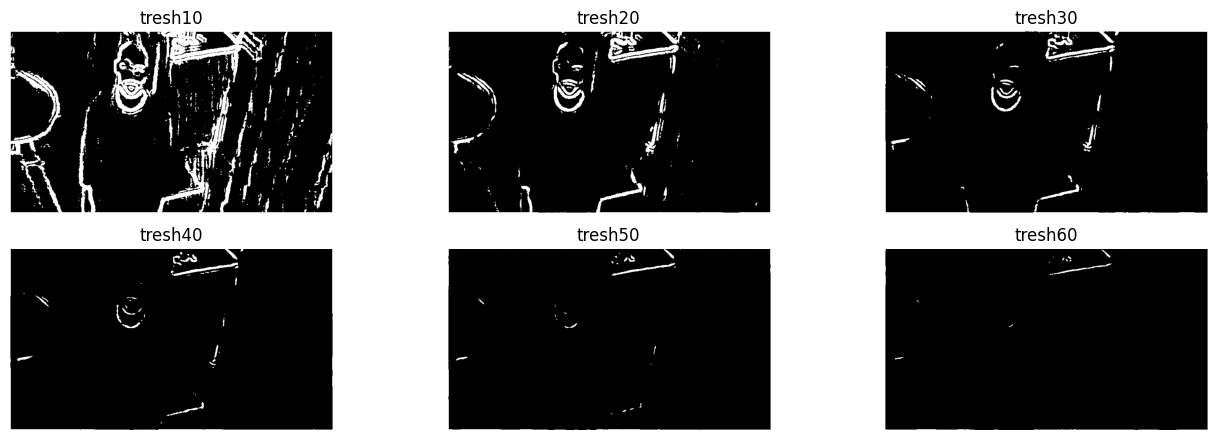

In [60]:
tresh10 = treshold_tepi(sobel, 10)
tresh20 = treshold_tepi(sobel, 20)
tresh30 = treshold_tepi(sobel, 30)
tresh40 = treshold_tepi(sobel, 40)
tresh50 = treshold_tepi(sobel, 50)
tresh60 = treshold_tepi(sobel, 60)

plt.figure(figsize=(16, 8))

plt.subplot(3, 3, 1)
plt.imshow(tresh10, cmap='gray')
plt.title("tresh10")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(tresh20, cmap='gray')
plt.title("tresh20")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(tresh30, cmap='gray')
plt.title("tresh30")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(tresh40, cmap='gray')
plt.title("tresh40")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(tresh50, cmap='gray')
plt.title("tresh50")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(tresh60, cmap='gray')
plt.title("tresh60")
plt.axis('off')

### Perbadingan hasil citra treshold
- Threshold 10: Paling banyak tepi yang muncul. Siluet orang terlihat lengkap, tapi gambar sangat ramai karena noise dan garis-garis kecil di background ikut terdeteksi. Banyak artefak yang mengganggu.
- Threshold 20: Sudah lebih bersih dibanding 10. Bentuk orang masih cukup lengkap, noise berkurang lumayan, tapi masih ada beberapa garis tidak penting di latar belakang.
- Threshold 30: Menurut saya ini adalah hasil yang paling seimbang. Siluet orang masih terlihat jelas (kepala, badan, dan tangan masih nyambung), noise sudah cukup berkurang, dan gambar tidak terlalu ramai.
- Threshold 40: Mulai kehilangan banyak detail. Bagian tangan dan beberapa tepi badan mulai putus-putus. Siluet orang masih kelihatan, tapi sudah agak kurang lengkap.
- Threshold 50: Citra mulai kosong. Hanya tersisa tepi-tepi yang sangat kuat saja. Bentuk orang sudah hampir tidak jelas, banyak bagian tubuh yang hilang.
- Threshold 60: Hampir semuanya hilang. Hanya ada sedikit garis putih kecil yang tersisa. Siluet orang nyaris tidak terbaca lagi.

Kesimpulan:
Nilai threshold yang paling bagus untuk citra CCTV ini adalah sekitar 30. Karena pada nilai tersebut keseimbangan antara menjaga bentuk siluet orang dan membersihkan noise paling optimal. Terlalu rendah menjadi terlalu noisy, terlalu tinggi mengakibatkan siluet orang hilang.

### Menaampilkan grid cctv
Kode di bawah digunakan untuk mengeksplorasi nilai warna piksel pada citra CCTV backup.jpg sebelum melakukan background removal atau masking. Lalu mencetak nilai BGR di beberapa titik penting: pada badan orang, background gelap, objek lain, dan background terang. Selain itu, menampilkan citra asli dengan grid merah dan koordinat agar memudahkan melihat posisi piksel yang sedang dianalisis.
Langkah ini sangat penting karena citra CCTV memiliki pencahayaan yang tidak merata, sehingga perlu mengetahui perbedaan nilai warna antara objek manusia dan latar belakang sebelum menentukan threshold yang tepat. Dengan mengetahui shape citra dan nilai piksel di berbagai area, bisa merancang strategi thresholding RGB yang lebih akurat untuk memisahkan siluet orang dari background.

Orang (badan): [121  99 118]
Background gelap: [148 102 124]
Objek lain: [184 219 232]
Background terang: [155 146 186]


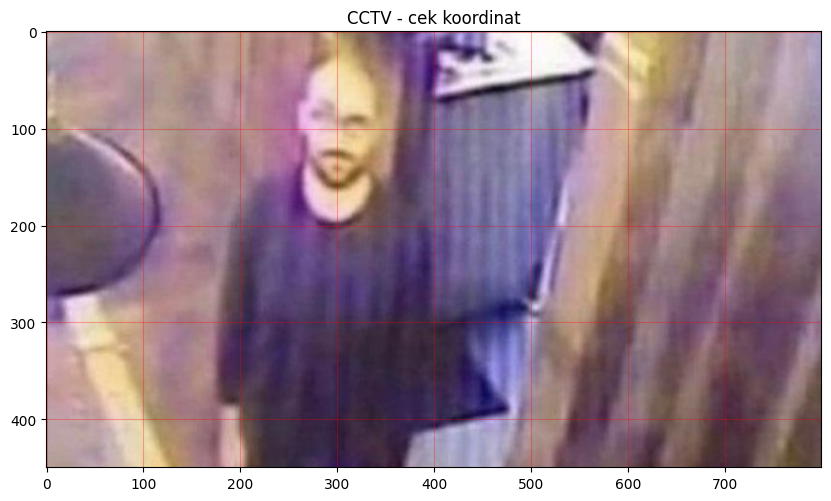

Shape: (450, 800, 3)


In [61]:
# Cek nilai BGR di berbagai area
print("Orang (badan):", cctv[200, 200])
print("Background gelap:", cctv[100, 400])
print("Objek lain:", cctv[300, 50])
print("Background terang:", cctv[50, 50])

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(cctv, cv.COLOR_BGR2RGB))
plt.grid(True, color='red', alpha=0.3)
plt.xticks(range(0, cctv.shape[1], 100))
plt.yticks(range(0, cctv.shape[0], 100))
plt.title("CCTV - cek koordinat")
plt.show()

print("Shape:", cctv.shape)

### Menampilkan citra siluet untuk medeteksi objek
Kode di atas adalah bagian paling penting dan kompleks di praktikum ini, yaitu membuat highlight siluet orang pada citra CCTV.
Selanjutnya, membuat mask manual dengan menentukan koordinat kotak untuk badan (x=170, y=50, lebar=250, tinggi=410) dan kepala (x=265, y=20, lebar=90, tinggi=180). Kemudian isi area tersebut dengan putih (255) jika nilai gray-nya cukup gelap (<= 105). Setelah itu rapikan mask menggunakan kombinasi filter median dan mean 3x3, lalu lakukan thresholding ulang agar mask lebih bersih.
Selanjutnya, buat outline_siluet dengan mendeteksi tepi mask (pixel putih yang bersisian dengan pixel hitam). Terakhir, buat citra highlight dengan memberikan warna kuning pada area siluet (campuran 55% kuning + 45% warna asli) dan outline kuning yang lebih tegas di tepinya.

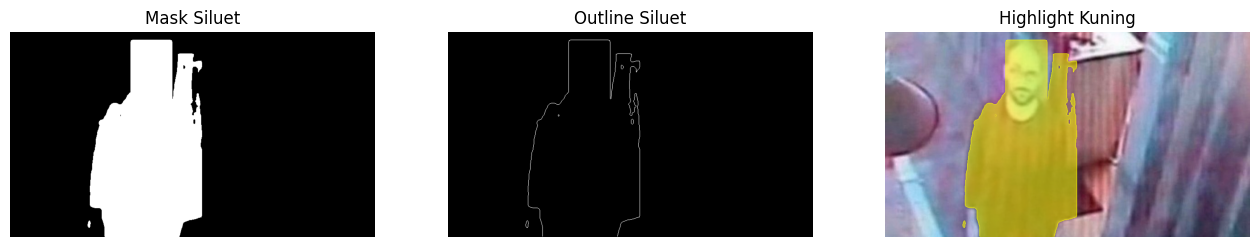

In [68]:
x_body, y_body = 170, 50
lebar_body = 250
tinggi_body = 410

x_kepala, y_kepala = 265, 20
lebar_kepala = 90
tinggi_kepala = 180

mask_siluet = np.zeros_like(cctv_gray, dtype=np.uint8)

# MASK BADAN
for i in range(cctv_gray.shape[0]):
    for j in range(cctv_gray.shape[1]):

        if (
            y_body <= i < y_body + tinggi_body and
            x_body <= j < x_body + lebar_body
        ):

            if cctv_gray[i, j] <= 105:
                mask_siluet[i, j] = 255

# MASK KEPALA
for i in range(y_kepala, y_kepala + tinggi_kepala):
    for j in range(x_kepala, x_kepala + lebar_kepala):

        mask_siluet[i, j] = 255

# RAPIIKAN MASK
mask_siluet = filter(mask_siluet, 3, 'median')
mask_siluet = filter(mask_siluet, 3, 'mean')
mask_siluet = filter(mask_siluet, 3, 'mean')

# THRESHOLD ULANG
for i in range(mask_siluet.shape[0]):
    for j in range(mask_siluet.shape[1]):

        if mask_siluet[i, j] > 80:
            mask_siluet[i, j] = 255
        else:
            mask_siluet[i, j] = 0


# OUTLINE SILUET
outline_siluet = np.zeros_like(
    cctv_gray,
    dtype=np.uint8
)

for i in range(1, mask_siluet.shape[0] - 1):
    for j in range(1, mask_siluet.shape[1] - 1):

        if mask_siluet[i, j] == 255:

            if (
                mask_siluet[i-1, j] == 0 or
                mask_siluet[i+1, j] == 0 or
                mask_siluet[i, j-1] == 0 or
                mask_siluet[i, j+1] == 0
            ):

                outline_siluet[i, j] = 255

# HIGHLIGHT KUNING
highlight = cctv.copy()

for i in range(mask_siluet.shape[0]):
    for j in range(mask_siluet.shape[1]):

        if mask_siluet[i, j] == 255:

            highlight[i, j] = (
                0.45 * cctv[i, j] +
                0.55 * np.array([255, 255, 0])
            ).astype(np.uint8)

# GARIS OUTLINE KUNING
for i in range(outline_siluet.shape[0]):
    for j in range(outline_siluet.shape[1]):

        if outline_siluet[i, j] == 255:

            highlight[i, j] = [255, 255, 0]

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_siluet, cmap='gray')
plt.title("Mask Siluet")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(outline_siluet, cmap='gray')
plt.title("Outline Siluet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highlight)
plt.title("Highlight Kuning")
plt.axis("off")

plt.show()

### Analisis percobaan siluet pertama
- Mask Siluet: Bentuk keseluruhan sudah cukup baik. Area badan dan kepala berhasil ditangkap dengan rapi. Namun, masih ada sedikit bagian yang kurang pas (terutama di bahu kanan dan kiri yang agak kotak-kotak karena masking manual).
- Outline Siluet: Outline-nya cukup tipis dan mengikuti bentuk mask. Beberapa bagian tepi masih agak putus-putus, terutama di area lengan dan bahu. Tapi secara keseluruhan sudah bisa menunjukkan kontur tubuh orang dengan jelas.
- Highlight Kuning: Ini adalah hasil akhirnya. Siluet orang sudah terhighlight dengan warna kuning yang cukup mencolok. Wajah dan badan terlihat jelas dibandingkan background yang tetap gelap. Warna kuningnya cukup natural karena dicampur dengan warna asli citra (bukan full kuning solid). Namun, highlight masih agak “kasar” di tepi dan ada sedikit leakage (warna kuning yang meluber) di beberapa bagian.

Kesimpulan:
Secara keseluruhan hasilnya sudah lumayan bagus untuk teknik manual. Siluet orang sudah jelas terlihat dan mudah dibedakan dari background. Kekurangannya adalah masking masih manual (kotak), sehingga bentuknya kurang mengikuti kontur tubuh secara presisi. Kalau mau lebih bagus, bisa ditambahkan masking yang lebih detail atau menggunakan hasil deteksi tepi untuk memperbaiki outline.

### Menampilkan citra siluet untuk medeteksi objek percobaan entah keberapa
Kode di bawah merupakan versi perbaikan dari pembuatan mask siluet sebelumnya. Alih-alih menggunakan kotak sederhana, kali ini mask dibuat dengan teknik fill polygon secara manual. Sebanyak 13 titik koordinat didefinisikan untuk mengikuti kontur kepala, bahu, badan, dan lengan orang. Kemudian fungsi fill_poly() dibuat untuk mengisi area di dalam polygon tersebut menjadi putih (255).
Setelah mask terbentuk, outline dihasilkan menggunakan fungsi edge() dengan kernel Sobel, lalu dilakukan thresholding manual agar hanya tepi yang kuat yang tersisa. Untuk highlight, citra asli dikonversi ke RGB dan dikombinasikan dengan warna kuning (65% warna asli + 35% kuning) pada area mask, sedangkan outline diberi warna kuning solid yang tegas.
Hasil akhir menunjukkan mask yang lebih mengikuti bentuk tubuh orang secara natural dibandingkan masking kotak sebelumnya.

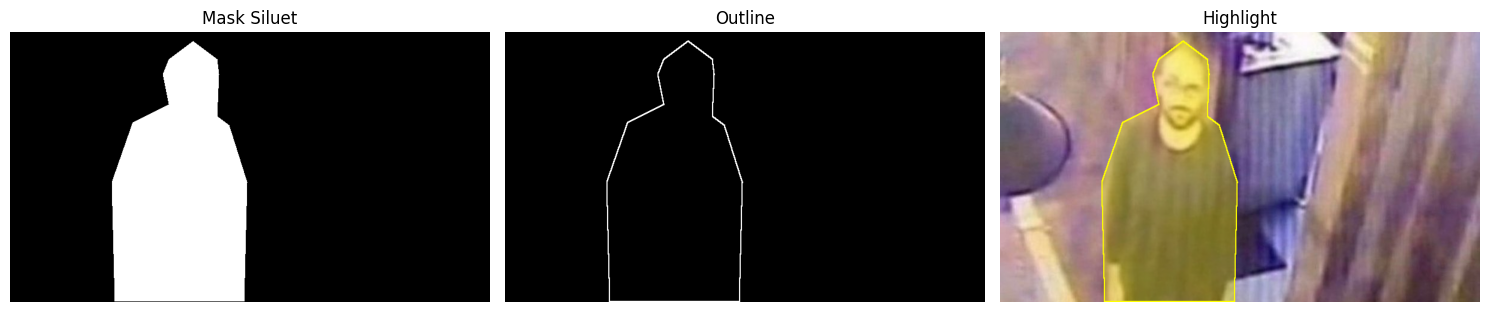

In [67]:
mask = np.zeros_like(cctv, dtype=np.uint8)

points = np.array([
   [345, 45],   # Sisi kanan kepala
    [348, 70],  # Telinga kanan
    [345, 140],  # leher kanan
    [365, 155],  # Bahu kanan
    [395, 250],  # Lengan kanan luar
    [390, 449],  # Badan bawah kanan
    [175, 449],  # Badan bawah kiri
    [170, 250],  # Lengan kiri luar
    [205, 150],  # Bahu kiri
    [265, 120],  # Leher kiri
    [255, 70],  # Telinga kiri
    [265, 45],  # Sisi kiri Kepala
    [305, 15],   # Puncak kepala
    
], dtype=np.int32)
def fill_poly(mask, points):
    h = mask.shape[0]
    w = mask.shape[1]
    n = points.shape[0]

    for y in range(h):
        intersections = np.zeros(n, dtype=np.int32)
        count = 0

        for i in range(n):
            x1 = points[i, 0]
            y1 = points[i, 1]
            x2 = points[(i + 1) % n, 0]
            y2 = points[(i + 1) % n, 1]

            if (y1 <= y < y2) or (y2 <= y < y1):
                x_intersect = int(x1 + (y - y1) * (x2 - x1) / (y2 - y1))
                intersections[count] = x_intersect
                count += 1

        for a in range(count):
            for b in range(count - a - 1):
                if intersections[b] > intersections[b + 1]:
                    temp = intersections[b]
                    intersections[b] = intersections[b + 1]
                    intersections[b + 1] = temp

        for i in range(0, count - 1, 2):
            x_start = intersections[i]
            x_end   = intersections[i + 1]
            for x in range(x_start, x_end + 1):
                if 0 <= x < w:
                    mask[y, x] = 255

    return mask

mask = np.zeros_like(cctv_gray, dtype=np.uint8)
mask = fill_poly(mask, points)

# outline dari mask pakai detect_edge
outline = edge(mask, sobelX, sobelY)

# threshold manual
outline_thresh = np.zeros_like(outline, dtype=np.uint8)
for baris in range(outline.shape[0]):
    for kolom in range(outline.shape[1]):
        if outline[baris, kolom] > 30:
            outline_thresh[baris, kolom] = 255
        else:
            outline_thresh[baris, kolom] = 0

# highlight pakai gambar orang (BGR → RGB dulu)
highlight = cv.cvtColor(cctv, cv.COLOR_BGR2RGB).copy()

highlight[mask == 255] = (
    0.65 * highlight[mask == 255] +
    0.35 * np.array([255, 255, 0])
).astype(np.uint8)

highlight[outline_thresh == 255] = [255, 255, 0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Mask Siluet")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Outline")
plt.imshow(outline_thresh, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Highlight")
plt.imshow(highlight)
plt.axis("off")

plt.tight_layout()
plt.show()

### Analisis hasil citra siluet objek
- Mask Siluet: Bentuknya sudah jauh lebih natural dibandingkan sebelumnya. Kontur kepala, bahu, dan badan mengikuti bentuk tubuh orang dengan lebih baik. Tidak lagi terlihat kotak-kotak seperti versi masking rectangle sebelumnya.
- Outline: Garis tepinya cukup tipis dan rapi. Meski masih ada sedikit bagian yang kurang sempurna (terutama di area kepala dan bahu), secara keseluruhan outline sudah mengikuti bentuk siluet dengan baik.
- Highlight: Siluet orang sudah tercover warna kuning dengan cukup merata. Wajah dan badan lebih mudah terlihat. Warna kuningnya tidak terlalu mencolok karena dicampur dengan warna asli citra.

Perbedaan dengan gambar sebelumnya (versi masking kotak):

- Bentuk siluet jauh lebih presisi dan natural, terutama di bagian kepala dan bahu yang sebelumnya terlihat kotak dan kaku.
- Mask mengikuti kontur tubuh dengan lebih baik, bukan hanya persegi panjang.
- Highlight terlihat lebih rapi dan profesional.

### Membaca dan menampilkan citra david
Kode di bawah digunakan untuk memuat citra pas foto david.jpg dan menampilkan perbandingan antara citra asli dengan citra grayscale. Citra asli dibaca menggunakan cv.imread(), kemudian dikonversi ke grayscale dengan cv.cvtColor() agar siap untuk proses deteksi tepi dan penghilangan background.

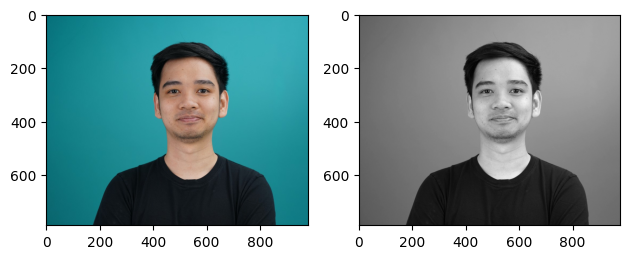

In [64]:
david = cv.imread("david.jpg")
david_gray = cv.cvtColor(david, cv.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(david, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(david_gray, cmap = 'gray')
plt.tight_layout()

### Menampilkan citra david hasil smoothing dan deteksi tepi
Kode di bawah digunakan untuk mendeteksi tepi pada citra pas foto david. Pertama, citra grayscale david dihaluskan menggunakan fungsi convolution dengan kernelSmoothing untuk mengurangi noise sebelum deteksi tepi dilakukan — ini penting karena citra pas foto memiliki detail wajah yang halus seperti alis, mata, dan kontur wajah yang bisa terganggu oleh noise. Selanjutnya, fungsi edge diterapkan menggunakan kernel Sobel untuk mendeteksi perubahan intensitas secara horizontal dan vertikal sehingga garis tepi wajah, rambut, dan pakaian dapat terlihat dengan jelas. Hasil deteksi tepi kemudian ditampilkan dalam mode grayscale untuk memperlihatkan garis-garis kontur objek pada citra.

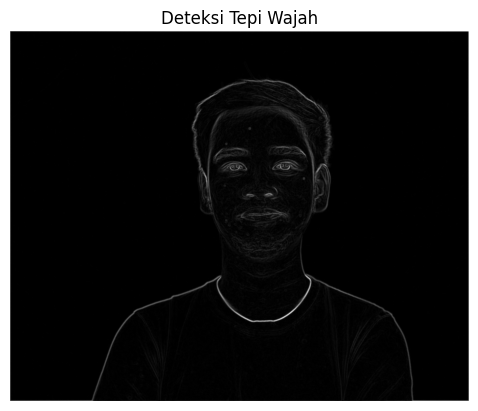

In [65]:
david_smooth = convolution(david_gray.astype(np.uint8), kernelSmoothing)
tepi_david = edge(david_smooth, sobelX, sobelY)

plt.imshow(tepi_david, cmap='gray')
plt.title("Deteksi Tepi Wajah")
plt.axis('off')
plt.show()

### Pemisahan Background dan Highlight Siluet Pas Foto David
Kode di bawah digunakan untuk memisahkan objek orang dari background berwarna toska pada citra pas foto david. Pertama, channel warna R, G, dan B dipisahkan dari citra untuk dianalisis secara individual. Background toska dideteksi berdasarkan karakteristik warnanya yaitu nilai channel G dan B yang jauh lebih tinggi dibanding channel R, kondisi ini ditulis sebagai G - R > 30 atau B - R > 30. Pendekatan ini dipilih karena grayscale tidak mampu membedakan background toska dari objek lain akibat nilai intensitasnya yang terlalu mirip, sehingga perbandingan antar channel RGB menjadi solusi yang lebih akurat.

Setelah background terdeteksi, siluet dibuat dengan membalik mask (~bg_mask) sehingga area yang bukan background (yaitu orang) menjadi putih dan background menjadi hitam. Selanjutnya, citra asli dikonversi ke RGB lalu area yang bukan bagian orang (siluet == 0) diganti dengan warna putih untuk menghasilkan tampilan background removal. Ketiga hasil yaitu deteksi tepi wajah, mask siluet, dan hasil background removal kemudian ditampilkan berdampingan untuk memperlihatkan keseluruhan proses transformasi citra dari deteksi tepi hingga penghilangan background.

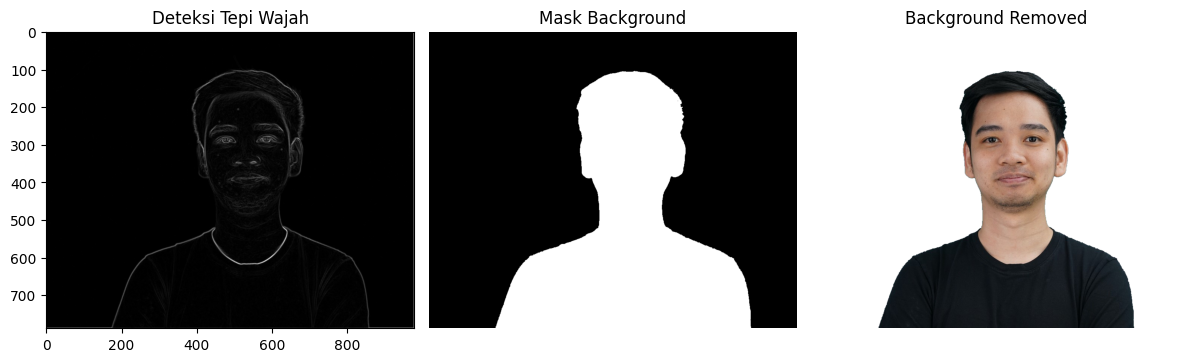

In [66]:
r = david[:, :, 2]
g = david[:, :, 1]
b = david[:, :, 0]

# Toska: G dan B tinggi, R rendah
bg_mask = (g.astype(np.int32) - r.astype(np.int32) > 30) | \
          (b.astype(np.int32) - r.astype(np.int32) > 30)

# Siluet: orang = putih, background = hitam
siluet = np.zeros_like(david_gray)
siluet[~bg_mask] = 255  # bukan background = orang = putih

hasil_david = david.copy()
hasil_david = cv.cvtColor(hasil_david, cv.COLOR_BGR2RGB)
hasil_david[siluet == 0] = [255, 255, 255]  # area hitam → putih

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(tepi_david, cmap='gray')
plt.title("Deteksi Tepi Wajah")

plt.subplot(1, 3, 2)
plt.imshow(siluet, cmap='gray')
plt.title("Mask Background"); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_david)
plt.title("Background Removed"); plt.axis('off')

plt.tight_layout()
plt.show()

### Analisis citra hasil deteksi tepi dan background removal
- Deteksi Tepi Wajah: Hasil deteksi tepi menggunakan Sobel berhasil menangkap garis kontur wajah, rambut, mata, hidung, bibir, dan pakaian dengan cukup jelas pada latar hitam. Tepi yang paling terang terlihat di area transisi antara wajah dan background toska karena perbedaan intensitasnya paling tajam. Area dalam wajah seperti tekstur kulit menghasilkan tepi yang lebih halus dan redup karena perubahan intensitasnya lebih gradual. Proses smoothing sebelum deteksi tepi berhasil mengurangi noise sehingga garis tepi yang dihasilkan lebih bersih dan tidak terlalu banyak noise titik.
- Mask Background: Siluet orang berhasil terbentuk secara solid putih dengan bentuk yang mengikuti kontur tubuh secara akurat termasuk rambut, wajah, leher, dan bahu. Background toska berhasil dipisahkan sepenuhnya menjadi hitam berkat pendekatan perbandingan channel RGB (G - R > 30 atau B - R > 30) yang mampu membedakan warna toska dari warna kulit, rambut, dan baju hitam meskipun nilai grayscalenya saling overlap. Hasilnya jauh lebih bersih dibandingkan pendekatan threshold grayscale biasa.
- Background Removed: Hasil akhir menunjukkan objek orang yang bersih dengan background putih solid. Detail wajah, rambut, dan pakaian tetap terjaga dengan baik tanpa ada piksel background yang tersisa. Ini membuktikan bahwa mask siluet yang dihasilkan cukup akurat untuk digunakan sebagai dasar penghilangan background, meskipun pada beberapa bagian tepi rambut masih terlihat sedikit kasar karena keterbatasan threshold berbasis warna tanpa morfologi tambahan.

## Kesimpulan

Pada praktikum Modul 3 ini telah dilakukan serangkaian proses perbaikan kualitas citra dan deteksi tepi pada dua objek citra yang berbeda yaitu citra CCTV berkualitas rendah (backup.jpg) dan pas foto bersih (david.jpg).

Pada citra CCTV, proses diawali dengan konversi ke grayscale dilanjutkan penerapan filter spasial yaitu mean, median, dan modus dengan ukuran kernel 3x3 dan 9x9. Mean filter menghasilkan efek blur merata di mana semakin besar kernel semakin halus gambar namun detail semakin hilang. Median filter terbukti paling efektif untuk menghilangkan noise titik tanpa merusak tepi objek. Modus filter menghasilkan efek posterisasi karena mengambil nilai piksel yang paling sering muncul di area kernel. Selain itu diterapkan juga smoothing dan sharpening berbasis konvolusi kernel, serta kombinasi keduanya yang menghasilkan citra lebih bersih sekaligus tajam, dimana cocok untuk meningkatkan kualitas citra CCTV.

Pada tahap deteksi tepi, operator Sobel, Prewitt, dan Roberts diterapkan pada citra yang telah dihaluskan. Sobel menghasilkan tepi paling stabil karena pembobotan di titik tengah membuatnya lebih tahan noise. Prewitt menghasilkan tepi yang mirip Sobel namun sedikit lebih sensitif terhadap noise. Roberts menggunakan kernel 2x2 diagonal sehingga paling cepat namun paling rentan noise. Kombinasi ketiga operator menghasilkan tepi yang lebih lengkap. Selanjutnya diterapkan threshold pada hasil deteksi tepi dengan berbagai nilai, threshold rendah menampilkan banyak tepi termasuk noise, sedangkan threshold tinggi hanya menyisakan tepi kuat saja. Nilai threshold optimal untuk citra CCTV ini berada di kisaran 20-30.

Untuk highlight siluet orang pada citra CCTV, pendekatan ROI (Region of Interest) digunakan dengan menentukan koordinat area orang terlebih dahulu sebelum threshold diterapkan. Hal ini dilakukan karena nilai RGB pada citra CCTV berkualitas rendah sangat mirip antara orang dan background sehingga threshold global tidak efektif. Dengan membatasi area analisis pada ROI, hasil siluet menjadi lebih fokus dan akurat.

Pada citra pas foto david, deteksi tepi menggunakan Sobel berhasil menangkap kontur wajah, rambut, dan pakaian dengan jelas berkat kualitas pencahayaan yang lebih baik. Untuk background removal, pendekatan threshold grayscale tidak berhasil karena nilai grayscale background toska overlap dengan nilai rambut dan baju hitam. Solusinya adalah menggunakan perbandingan channel RGB di mana background toska memiliki nilai G dan B yang jauh lebih tinggi dari R. Pendekatan ini berhasil menghasilkan siluet solid yang akurat sehingga background dapat dihilangkan dan diganti warna putih dengan hasil yang bersih.

Secara keseluruhan, praktikum ini membuktikan bahwa perbaikan kualitas citra melalui filter spasial sangat berpengaruh terhadap hasil deteksi tepi — citra yang lebih bersih menghasilkan tepi yang lebih akurat. Pemilihan metode yang tepat harus disesuaikan dengan karakteristik citra, di mana citra berkualitas rendah seperti CCTV membutuhkan pendekatan yang lebih kompleks dibandingkan citra bersih seperti pas foto.

## Kendala atau Masalah yang di alami selama mengerjakan
Selama proses pengerjaan praktikum ini, terdapat beberapa kendala yang ditemukan. Pertama, hasil mean filter pada awalnya menghasilkan output yang berantakan dan penuh noise karena tipe data array padding menggunakan uint8 yang menyebabkan integer overflow saat proses penjumlahan piksel. Masalah ini diselesaikan dengan mengganti tipe data padding menjadi int32 agar tidak terjadi overflow.

Kedua, pada proses highlight siluet orang di citra CCTV, nilai RGB antara orang dan background sangat mirip sehingga threshold global selalu ikut mendeteksi area lain di luar orang. Solusinya adalah menggunakan pendekatan ROI dengan membatasi area analisis hanya pada koordinat orang terlebih dahulu sebelum threshold diterapkan.

Ketiga, pada proses pembuatan siluet citra pas foto david, pendekatan threshold grayscale tidak berhasil karena nilai intensitas background toska ternyata overlap dengan nilai rambut dan baju hitam. Setelah dilakukan pengecekan nilai piksel per area, ditemukan bahwa background toska memiliki nilai 89 sedangkan rambut 124 dan baju 115, sehingga tidak bisa dipisahkan dengan threshold sederhana. Solusinya adalah menggunakan perbandingan channel RGB yang memanfaatkan karakteristik warna toska yaitu nilai G dan B yang jauh lebih tinggi dari R.

Keempat, hasil konvolusi untuk smoothing dan sharpening menghasilkan tipe data float32 yang menyebabkan tampilan gambar menjadi tidak normal saat ditampilkan. Masalah ini diselesaikan dengan menambahkan np.clip dan konversi ke uint8 setelah proses konvolusi selesai.